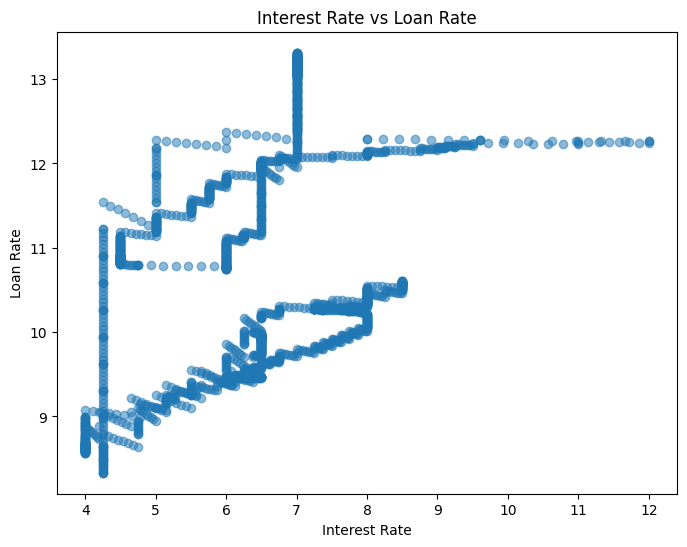

C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Mean Absolute Error: 0.68
R-squared Score: 0.53


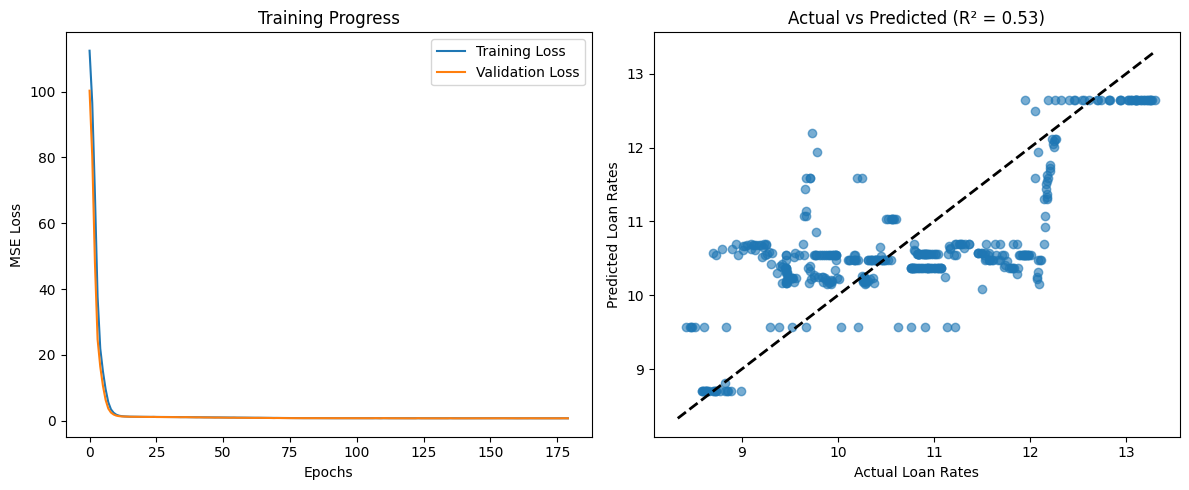

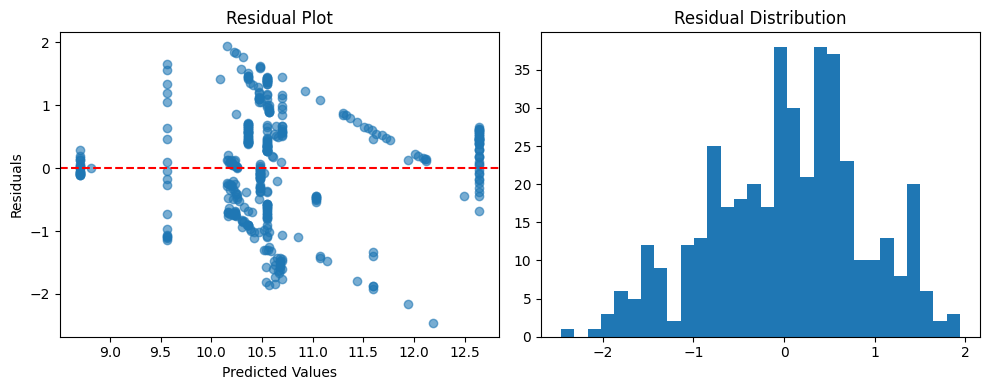

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


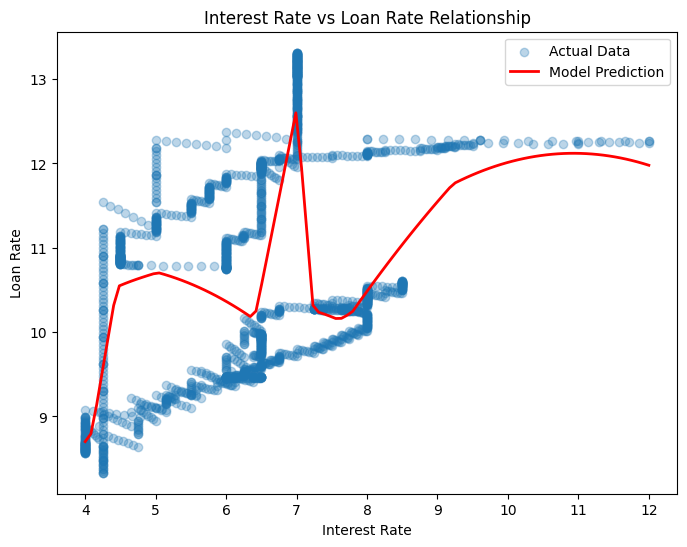

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import joblib

# Load and inspect data
data = pd.read_csv('Interest Rate and Loan Rate.csv')
data = data.dropna(subset=['Average', 'Loan Rate'])

# Visualize the raw data relationship
plt.figure(figsize=(8, 6))
plt.scatter(data['Average'], data['Loan Rate'], alpha=0.5)
plt.title('Interest Rate vs Loan Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Loan Rate')
plt.show()

# Check for and remove outliers
q1 = data['Loan Rate'].quantile(0.25)
q3 = data['Loan Rate'].quantile(0.75)
iqr = q3 - q1
data = data[(data['Loan Rate'] > q1 - 1.5*iqr) & (data['Loan Rate'] < q3 + 1.5*iqr)]

# Feature engineering - add polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(data[['Average']])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_poly, data['Loan Rate'], 
                                                    test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build improved model
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

# Custom optimizer with lower learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train model
history = model.fit(X_train_scaled, y_train,
                    validation_split=0.2,
                    epochs=500,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=0)

# Save artifacts
model.save('improved_loan_rate_model.h5')
joblib.dump(poly, 'poly_features.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Plot training progress
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Progress')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

# Predictions and evaluation
y_pred = model.predict(X_test_scaled).flatten()
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

# Actual vs Predicted plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Loan Rates')
plt.ylabel('Predicted Loan Rates')
plt.title(f'Actual vs Predicted (R² = {r2:.2f})')
plt.tight_layout()
plt.show()

# Residual analysis
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30)
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

# Generate prediction curve
x_range = np.linspace(data['Average'].min(), data['Average'].max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
x_range_scaled = scaler.transform(x_range_poly)
y_range = model.predict(x_range_scaled).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(data['Average'], data['Loan Rate'], alpha=0.3, label='Actual Data')
plt.plot(x_range, y_range, 'r-', lw=2, label='Model Prediction')
plt.xlabel('Interest Rate')
plt.ylabel('Loan Rate')
plt.title('Interest Rate vs Loan Rate Relationship')
plt.legend()
plt.show()

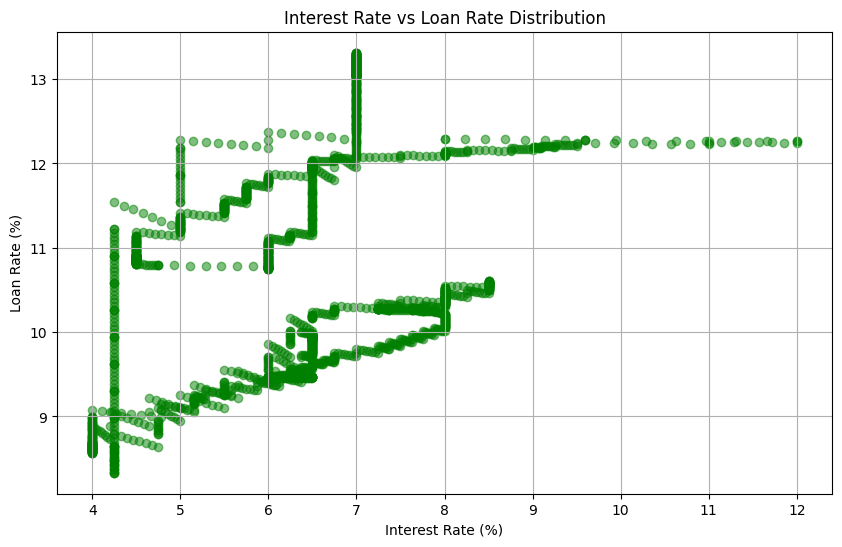

C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Cross-Validation MAE: 0.69 ± 0.02
Cross-Validation R²: 0.55 ± 0.03


C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Final Test Performance:
MAE: 0.69
MSE: 0.72
RMSE: 0.85
R²: 0.53


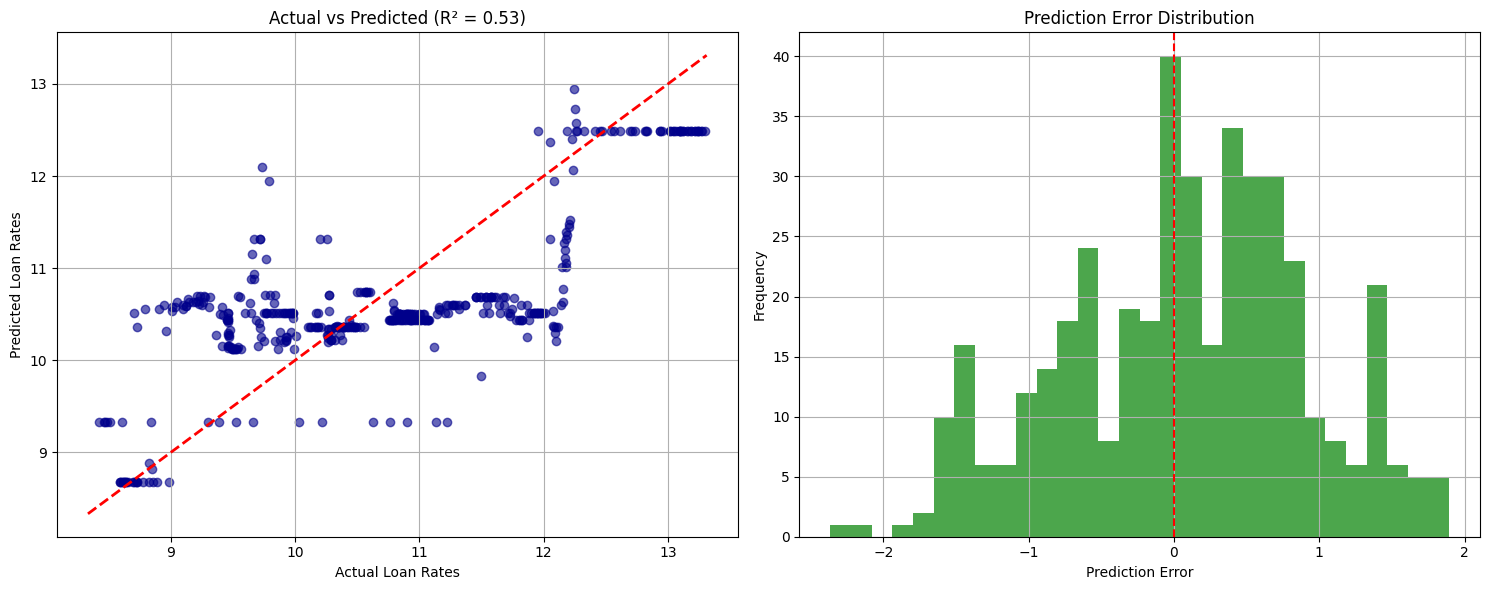


Feature Importance:
     Feature    Weight
0    Average -0.003688
1  Average^2  0.003414
2  Average^3 -0.001711


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf 
import joblib

# Load and prepare data
data = pd.read_csv('Interest Rate and Loan Rate.csv').dropna()
X = data[['Average']]  # Interest Rate
y = data['Loan Rate']  # Target

# Enhanced data visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, c='green')
plt.title('Interest Rate vs Loan Rate Distribution')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Loan Rate (%)')
plt.grid(True)
plt.show()

# Advanced preprocessing
# 1. Handle outliers using IQR with stricter bounds
Q1 = y.quantile(0.15)
Q3 = y.quantile(0.85)
IQR = Q3 - Q1
data = data[(y >= Q1 - 1.5*IQR) & (y <= Q3 + 1.5*IQR)]

# 2. Polynomial feature expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(data[['Average']])

# 3. Robust scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_poly)

# K-Fold cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []
r2_scores = []

# Model configuration
def build_model():
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(0.01), 
              input_shape=(X_scaled.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1)
    ])
    
    optimizer = Adam(learning_rate=0.0005)
    # Use the Huber loss function directly from tf.keras.losses
    model.compile(optimizer=optimizer, 
                loss=tf.keras.losses.Huber(),  # Changed here
                metrics=['mae'])
    return model

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

# Cross-validation training
for train_index, val_index in kf.split(X_scaled):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    model = build_model()
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=300,
                        batch_size=32,
                        callbacks=[early_stop, reduce_lr],
                        verbose=0)
    
    # Predict and store metrics
    y_pred = model.predict(X_val).flatten()
    mae_scores.append(mean_absolute_error(y_val, y_pred))
    r2_scores.append(r2_score(y_val, y_pred))

print(f"Cross-Validation MAE: {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")
print(f"Cross-Validation R²: {np.mean(r2_scores):.2f} ± {np.std(r2_scores):.2f}")

# Final model training
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
final_model = build_model()
history = final_model.fit(X_train, y_train,
                          validation_split=0.2,
                          epochs=300,
                          batch_size=32,
                          callbacks=[early_stop, reduce_lr],
                          verbose=0)

# Save artifacts
final_model.save('final_loan_model.h5')
joblib.dump(poly, 'poly_transformer.pkl')
joblib.dump(scaler, 'robust_scaler.pkl')

# Enhanced visualization
def plot_results(y_true, y_pred):
    plt.figure(figsize=(15, 6))
    
    # Prediction plot
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.6, c='darkblue')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel('Actual Loan Rates')
    plt.ylabel('Predicted Loan Rates')
    plt.title(f'Actual vs Predicted (R² = {r2_score(y_true, y_pred):.2f})')
    plt.grid(True)
    
    # Error distribution
    plt.subplot(1, 2, 2)
    errors = y_true - y_pred
    plt.hist(errors, bins=30, color='green', alpha=0.7)
    plt.title('Prediction Error Distribution')
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.axvline(0, color='r', linestyle='--')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Evaluate on test set
y_pred = final_model.predict(X_test).flatten()
print("\nFinal Test Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

plot_results(y_test, y_pred)

# Feature importance analysis
weights = final_model.layers[0].get_weights()[0]
poly_features = poly.get_feature_names_out(['Average'])
feature_importance = pd.DataFrame({
    'Feature': poly_features,
    'Weight': weights[:, 0]
}).sort_values('Weight', key=abs, ascending=False)

print("\nFeature Importance:")
print(feature_importance)